<a href="https://colab.research.google.com/github/Nithin-M11/ai-student-learning-insights/blob/main/AI_Student_Learning_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Student Report & Learning Insights

## Project Overview

This project analyzes student academic performance and generates
personalized learning insights based on academic and behavioral data.

### Current Objectives
- Analyze student performance
- Identify factors associated with academic performance
- Identify strongest and weakest subjects
- Generate personalized learning recommendations
- Build a machine learning model for performance prediction
- Eventually generate AI-powered student reports

### Current Stage
Milestone 1: Dataset Generation & Initial Exploratory Data Analysis

In [237]:
import numpy as np

study_hours = np.random.randint(5, 21, 10)

print(study_hours)

[17 17 18 19  5 20 11 20  7 14]


## 1. Dataset Generation

In [238]:
import numpy as np

np.random.seed(42)

n_students = 1000

study_hours = np.random.randint(5, 21, n_students)
attendance = np.random.randint(50, 101, n_students)
assignment_score = np.random.randint(40, 101, n_students)
previous_score = np.random.randint(40, 101, n_students)

maths = np.random.randint(40, 101, n_students)
dbms = np.random.randint(40, 101, n_students)
python_score = np.random.randint(40, 101, n_students)
os = np.random.randint(40, 101, n_students)
ml = np.random.randint(40, 101, n_students)

### 1.1 Generating Current Performance Score

In [239]:
current_score = (
    0.20 * (study_hours / 20 * 100) +
    0.15 * attendance +
    0.15 * assignment_score +
    0.15 * previous_score +
    0.07 * maths +
    0.07 * dbms +
    0.07 * python_score +
    0.07 * os +
    0.07 * ml
)

# Add natural variation
noise = np.random.normal(0, 4, n_students)

current_score = current_score + noise

# Keep scores between 0 and 100
current_score = np.clip(current_score, 0, 100)

current_score = np.round(current_score, 2)

In [240]:
print(current_score[:10])

print("Minimum:", current_score.min())
print("Maximum:", current_score.max())
print("Average:", current_score.mean())

[69.96 51.22 61.19 77.91 68.46 60.47 77.04 65.43 70.96 51.07]
Minimum: 46.66
Maximum: 100.0
Average: 69.45427


In [241]:
print(study_hours[:10])
print(attendance[:10])
print(maths[:10])

[11  8 17 19 15 12 17  9 11 14]
[66 58 82 69 62 77 97 78 62 95]
[79 95 67 86 78 45 48 59 99 40]


### 1.2 Performance Level Classification

In [242]:
performance_level = np.where(
    current_score >= 90, "Excellent",
    np.where(
        current_score >= 75, "Good",
        np.where(
            current_score >= 60, "Average",
            "Needs Improvement"
        )
    )
)

print(performance_level[:20])

['Average' 'Needs Improvement' 'Average' 'Good' 'Average' 'Average' 'Good'
 'Average' 'Average' 'Needs Improvement' 'Average' 'Average' 'Average'
 'Good' 'Average' 'Average' 'Average' 'Average' 'Good' 'Average']


In [243]:
unique, counts = np.unique(performance_level, return_counts=True)

for category, count in zip(unique, counts):
    print(category, ":", count)

Average : 606
Excellent : 4
Good : 258
Needs Improvement : 132


In [244]:
print("Minimum:", current_score.min())
print("Maximum:", current_score.max())
print("Mean:", current_score.mean())
print("Median:", np.median(current_score))

Minimum: 46.66
Maximum: 100.0
Mean: 69.45427
Median: 69.12


## 2. Creating the Student DataFrame

In [245]:
import pandas as pd

data = {
    "student_id": [f"ST{i:04d}" for i in range(1, n_students + 1)],
    "study_hours": study_hours,
    "attendance": attendance,
    "assignment_score": assignment_score,
    "previous_score": previous_score,
    "maths": maths,
    "dbms": dbms,
    "python": python_score,
    "os": os,
    "ml": ml,
    "current_score": current_score,
    "performance_level": performance_level
}

df = pd.DataFrame(data)

In [246]:
df.head()

,student_id,study_hours,attendance,assignment_score,previous_score,maths,dbms,python,os,ml,current_score,performance_level
0,ST0001,11,66,64,59,79,65,94,89,46,69.96,Average
1,ST0002,8,58,44,45,95,77,79,59,61,51.22,Needs Improvement
2,ST0003,17,82,50,61,67,40,60,51,56,61.19,Average
3,ST0004,19,69,98,57,86,59,41,62,57,77.91,Good
4,ST0005,15,62,73,47,78,94,76,43,88,68.46,Average


In [247]:
df.shape

(1000, 12)

## 3. Exploratory Data Analysis

### 3.1 Data Information and Summary

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         1000 non-null   object 
 1   study_hours        1000 non-null   int64  
 2   attendance         1000 non-null   int64  
 3   assignment_score   1000 non-null   int64  
 4   previous_score     1000 non-null   int64  
 5   maths              1000 non-null   int64  
 6   dbms               1000 non-null   int64  
 7   python             1000 non-null   int64  
 8   os                 1000 non-null   int64  
 9   ml                 1000 non-null   int64  
 10  current_score      1000 non-null   float64
 11  performance_level  1000 non-null   object 
dtypes: float64(1), int64(9), object(2)
memory usage: 93.9+ KB


In [249]:
df.describe()

,study_hours,attendance,assignment_score,previous_score,maths,dbms,python,os,ml,current_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,12.570000,75.354000,69.606000,69.774000,70.458000,70.531000,70.756000,70.414000,70.668000,69.454270
std,4.666785,14.912984,17.526093,17.513185,17.414003,17.830731,17.500878,17.721587,17.653992,7.927453
min,5.000000,50.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,46.660000
25%,8.000000,62.000000,54.000000,55.000000,56.000000,56.000000,56.000000,55.000000,56.000000,63.987500
50%,13.000000,75.000000,69.500000,69.000000,71.000000,71.000000,70.000000,70.000000,70.000000,69.120000
75%,17.000000,88.000000,84.250000,85.000000,85.250000,86.000000,86.000000,86.000000,86.000000,75.235000
max,20.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [250]:
df.isnull().sum()

,0
student_id,0
study_hours,0
attendance,0
assignment_score,0
previous_score,0
maths,0
dbms,0
python,0
os,0
ml,0


In [251]:
df["performance_level"].value_counts()

,count
performance_level,
Average,606
Good,258
Needs Improvement,132
Excellent,4


### 3.2 Study Hours vs Current Score

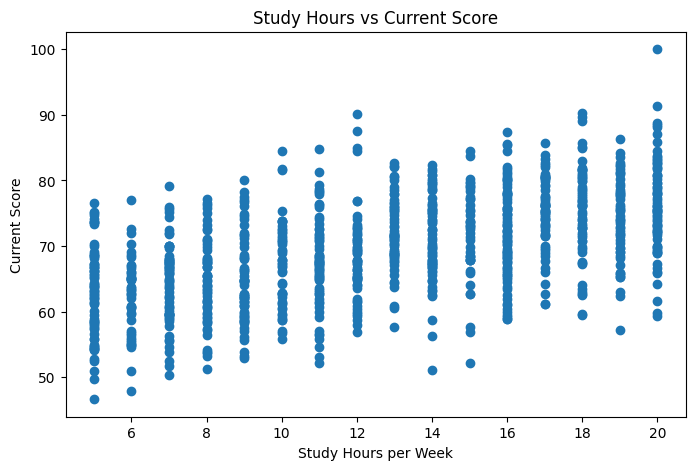

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["study_hours"], df["current_score"])

plt.xlabel("Study Hours per Week")
plt.ylabel("Current Score")
plt.title("Study Hours vs Current Score")

plt.show()

In [253]:
correlation = df["study_hours"].corr(df["current_score"])

print("Correlation:", correlation)

Correlation: 0.5588412156430693


### 3.3 Attendance vs Current Score

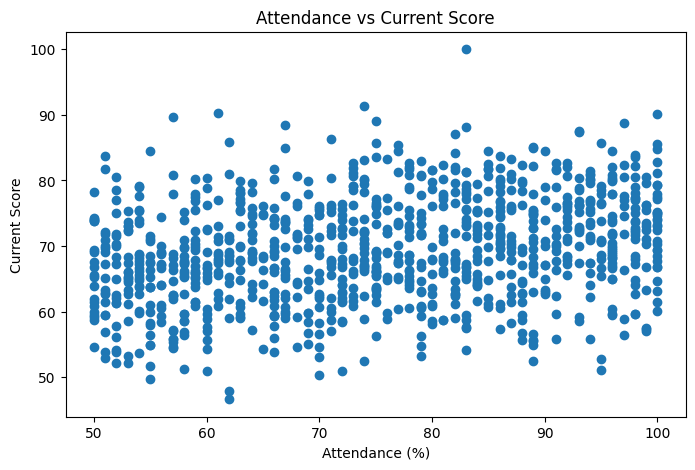

In [254]:
plt.figure(figsize=(8, 5))

plt.scatter(df["attendance"], df["current_score"])

plt.xlabel("Attendance (%)")
plt.ylabel("Current Score")
plt.title("Attendance vs Current Score")

plt.show()

In [255]:
correlation_attendance = df["attendance"].corr(df["current_score"])

print("Attendance Correlation:", correlation_attendance)

Attendance Correlation: 0.2827046308901737


### 3.4 Assignment Score vs Current Score

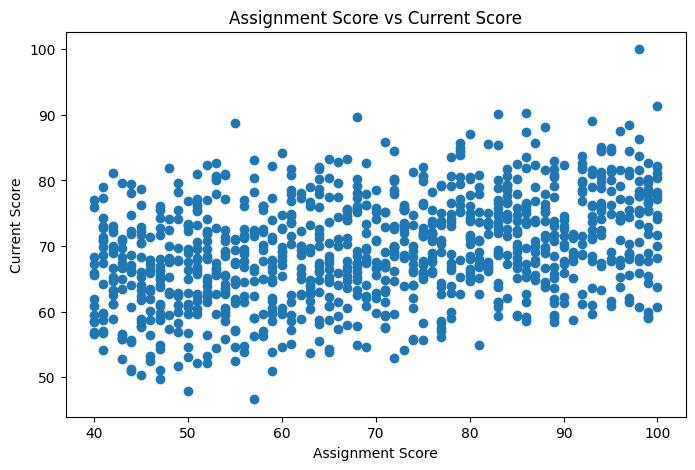

In [256]:
plt.figure(figsize=(8, 5))

plt.scatter(df["assignment_score"], df["current_score"])

plt.xlabel("Assignment Score")
plt.ylabel("Current Score")
plt.title("Assignment Score vs Current Score")

plt.show()

In [257]:
assignment_correlation = df["assignment_score"].corr(df["current_score"])

print("Assignment Correlation:", assignment_correlation)

Assignment Correlation: 0.3662776702689796


### 3.5 Previous Score vs Current Score

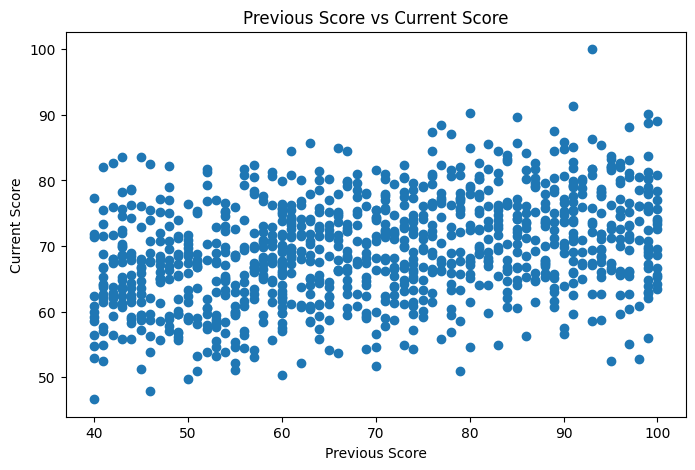

In [258]:
plt.figure(figsize=(8, 5))

plt.scatter(df["previous_score"], df["current_score"])

plt.xlabel("Previous Score")
plt.ylabel("Current Score")
plt.title("Previous Score vs Current Score")

plt.show()

In [259]:
previous_correlation = df["previous_score"].corr(df["current_score"])

print("Previous Score Correlation:", previous_correlation)

Previous Score Correlation: 0.34507957006312506


### 3.6 Correlation Analysis

In [260]:
correlation_matrix = df.corr(numeric_only=True)

correlation_with_score = correlation_matrix["current_score"].sort_values(
    ascending=False
)

print(correlation_with_score)

current_score       1.000000
study_hours         0.558841
assignment_score    0.366278
previous_score      0.345080
attendance          0.282705
python              0.170677
maths               0.160816
ml                  0.147576
os                  0.146165
dbms                0.131111
Name: current_score, dtype: float64


In [261]:
df.corr(numeric_only=True)

,study_hours,attendance,assignment_score,previous_score,maths,dbms,python,os,ml,current_score
study_hours,1.000000,-0.014754,0.012172,0.011376,-0.027776,-0.059061,-0.000881,-0.038925,-0.051902,0.558841
attendance,-0.014754,1.000000,0.038584,0.039565,0.013656,-0.006166,0.013909,0.022046,0.007834,0.282705
assignment_score,0.012172,0.038584,1.000000,0.018273,0.037523,0.006413,0.031173,0.004474,0.049238,0.366278
previous_score,0.011376,0.039565,0.018273,1.000000,0.015353,-0.043066,-0.006189,-0.013090,-0.000793,0.345080
maths,-0.027776,0.013656,0.037523,0.015353,1.000000,-0.018431,0.020386,0.025308,0.028908,0.160816
dbms,-0.059061,-0.006166,0.006413,-0.043066,-0.018431,1.000000,0.027339,0.044892,0.033232,0.131111
python,-0.000881,0.013909,0.031173,-0.006189,0.020386,0.027339,1.000000,0.029936,-0.016232,0.170677
os,-0.038925,0.022046,0.004474,-0.013090,0.025308,0.044892,0.029936,1.000000,-0.028926,0.146165
ml,-0.051902,0.007834,0.049238,-0.000793,0.028908,0.033232,-0.016232,-0.028926,1.000000,0.147576
current_score,0.558841,0.282705,0.366278,0.345080,0.160816,0.131111,0.170677,0.146165,0.147576,1.000000


## 4. Subject-Level Analysis


In [262]:
subjects = ["maths", "dbms", "python", "os", "ml"]

df["strongest_subject"] = df[subjects].idxmax(axis=1)
df["weakest_subject"] = df[subjects].idxmin(axis=1)

In [263]:
df[[
    "student_id",
    "maths",
    "dbms",
    "python",
    "os",
    "ml",
    "strongest_subject",
    "weakest_subject"
]].head(10)

,student_id,maths,dbms,python,os,ml,strongest_subject,weakest_subject
0,ST0001,79,65,94,89,46,python,ml
1,ST0002,95,77,79,59,61,maths,os
2,ST0003,67,40,60,51,56,maths,dbms
3,ST0004,86,59,41,62,57,maths,python
4,ST0005,78,94,76,43,88,dbms,os
5,ST0006,45,67,45,62,80,ml,maths
6,ST0007,48,55,83,87,49,os,maths
7,ST0008,59,86,57,94,49,os,ml
8,ST0009,99,56,69,87,96,maths,dbms
9,ST0010,40,79,61,40,46,dbms,maths


In [264]:
subjects = ["maths", "dbms", "python", "os", "ml"]

df["strongest_subject"] = df[subjects].idxmax(axis=1)
df["weakest_subject"] = df[subjects].idxmin(axis=1)